In [67]:
import pandas as pd
import numpy as np
import sklearn.metrics as sk_metrics
from scipy.stats import pearsonr
from scipy import stats
import matplotlib.pyplot as plt
import pingouin as pg
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import chi2 as chi2_dist
from semopy import Model, calc_stats

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")

In [68]:
VERSION = 'kw19_withoutCohortB'
VERSION = "wavlm_deberta"

FEATURE_SET = "full"
FEATURE_SET = "demographic_node_text_node_audio_task"
FEATURE_SET = "demographic_linguistic_acoustic_task"

n_bootsrap_samples = 1000

# Cohort definitions: (label, wave_a, wave_b)
COHORTS = [
    ('A', 'wave1', 'wave2'),
    ('B', 'wave2', 'wave3'),
]

target = 'language'

results = {'A': {}, 'B': {}}

## Load longitudinal data for both cohorts

In [69]:
def load_longitudinal(version, cohort_label):
    path = f"transformed_data/{version}_{FEATURE_SET}_predictions_targets_longitudinal_cohort{cohort_label}.csv"
    return pd.read_csv(path, header=[0, 1, 2], index_col=0)


longitudinal_by_cohort = {
    label: load_longitudinal(VERSION, label) for label, _, _ in COHORTS
}

for label, wave_a, wave_b in COHORTS:
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}): shape = {longitudinal_by_cohort[label].shape}')
    results[label]['n'] = longitudinal_by_cohort[label].shape[0]

Cohort A (wave1 ↔ wave2): shape = (305, 10)
Cohort B (wave2 ↔ wave3): shape = (70, 10)


## Test-retest reliability (ICC) of targets and predictions

In [70]:
def calculate_test_retest(longitudinal, target, wave_a, wave_b):
    test_retest_data_long = pd.DataFrame({
        'score': pd.concat((
            longitudinal[(wave_a, target, 'target')],
            longitudinal[(wave_b, target, 'target')],
        ), axis=0, ignore_index=True),
        'time': pd.concat((
            pd.Series(wave_a, index=longitudinal.index),
            pd.Series(wave_b, index=longitudinal.index),
        ), axis=0, ignore_index=True),
        'participant': pd.concat((
            pd.Series(longitudinal.index),
            pd.Series(longitudinal.index),
        ), axis=0, ignore_index=True),
    })
    icc_result = pg.intraclass_corr(
        data=test_retest_data_long, targets='participant', raters='time',
        ratings='score', nan_policy='omit',
    )
    icc_31 = icc_result.loc[icc_result['Type'] == 'ICC3', 'ICC'].values[0]
    return icc_31


def calculate_test_retest_predictions(longitudinal, target, task, wave_a, wave_b):
    test_retest_data_long = pd.DataFrame({
        'score': pd.concat((
            longitudinal[(wave_a, target, task)],
            longitudinal[(wave_b, target, task)],
        ), axis=0, ignore_index=True),
        'time': pd.concat((
            pd.Series(wave_a, index=longitudinal.index),
            pd.Series(wave_b, index=longitudinal.index),
        ), axis=0, ignore_index=True),
        'participant': pd.concat((
            pd.Series(longitudinal.index),
            pd.Series(longitudinal.index),
        ), axis=0, ignore_index=True),
    })
    icc_result = pg.intraclass_corr(
        data=test_retest_data_long, targets='participant', raters='time',
        ratings='score', nan_policy='omit',
    )
    icc_31 = icc_result.loc[icc_result['Type'] == 'ICC3', 'ICC'].values[0]
    return icc_31


for label, wave_a, wave_b in COHORTS:
    r = calculate_test_retest(longitudinal_by_cohort[label], target, wave_a, wave_b)
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}) — ICC31 ({target}): {r:.2f}')
    results[label][f'ICC_{target}'] = r

Cohort A (wave1 ↔ wave2) — ICC31 (language): 0.68
Cohort B (wave2 ↔ wave3) — ICC31 (language): 0.72


## Add average-prediction columns per cohort

In [71]:
def get_col(task, wave, target):
    return (wave, target, task)


tasks = ['cookieTheft', 'picnicScene', 'journaling']
all_targets = ['language', 'executive_function', 'speed', 'memory']


def add_average_predictions(longitudinal, wave_a, wave_b, tasks, all_targets):
    """Add per-wave avg_speech_prediction and avg_cookieTheft_picnicScene
    columns to a longitudinal frame, for every target available in the frame."""
    longitudinal = longitudinal.copy()
    for wave in [wave_a, wave_b]:
        for target_here in all_targets:
            # Only act if columns exist for this target/wave combo
            available_tasks = [
                t for t in tasks if (wave, target_here, t) in longitudinal.columns
            ]
            if not available_tasks:
                continue
            task_cols = [(wave, target_here, t) for t in available_tasks]
            longitudinal[(wave, target_here, 'avg_speech_prediction')] = (
                longitudinal[task_cols].mean(axis=1)
            )
            pic_tasks = [
                t for t in ['picnicScene', 'cookieTheft']
                if (wave, target_here, t) in longitudinal.columns
            ]
            if pic_tasks:
                pic_cols = [(wave, target_here, t) for t in pic_tasks]
                longitudinal[(wave, target_here, 'avg_cookieTheft_picnicScene')] = (
                    longitudinal[pic_cols].mean(axis=1)
                )
    return longitudinal.sort_index(axis=1, level=[0, 1, 2])


for label, wave_a, wave_b in COHORTS:
    longitudinal_by_cohort[label] = add_average_predictions(
        longitudinal_by_cohort[label], wave_a, wave_b, tasks, all_targets,
    )

longitudinal_by_cohort['A'].head()

wave1                        \
                                            language                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                  0.085508              0.157440   
0367083668                                  0.405482              0.266387   
048eb2a01e                                  0.703290              0.821310   
049af4901b                                 -0.329112             -0.205512   
04d9f72ef8                                 -0.212296             -0.353153   

                                                                              \
                                                                               
                         cookieTheft journaling picnicScene    target   wave   
sample_name_longitudinal                                                       
01d1fdfc3a                 -0.078487   0.301303    0.249503 -0.092677  wave1   
0367083668                  0.485050  -0.011802    0.325914  1.124401  wave1   
048eb2a01e                  0.649629   1.057351    0.756952  0.894593  wave1   
049af4901b                 -0.243929   0.041686   -0.414294  0.983548  wave1   
04d9f72ef8                 -0.106552  -0.634867   -0.318040  0.588701  wave1   

                                               wave2                        \
                                            language                         
                         avg_cookieTheft_picnicScene avg_speech_prediction   
sample_name_longitudinal                                                     
01d1fdfc3a                                 -0.210858             -0.152598   
0367083668                                  0.113253              0.268457   
048eb2a01e                                  0.297847              0.404463   
049af4901b                                 -0.475295             -0.284540   
04d9f72ef8                                 -0.232704             -0.234091   

                                                                              
                                                                              
                         cookieTheft journaling picnicScene    target   wave  
sample_name_longitudinal                                                      
01d1fdfc3a                 -0.428008  -0.036078    0.006293 -0.688462  wave2  
0367083668                  0.320958   0.578866   -0.094453  2.241093  wave2  
048eb2a01e                  0.233801   0.617694    0.361893  0.317482  wave2  
049af4901b                 -0.057945   0.096970   -0.892645  0.834917  wave2  
04d9f72ef8                 -0.327520  -0.236866   -0.137888 -0.148855  wave2

In [72]:
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) ===')
    long_df = longitudinal_by_cohort[label]
    for task in ['cookieTheft', 'picnicScene', 'journaling',
                 'avg_speech_prediction', 'avg_cookieTheft_picnicScene']:
        r_here = calculate_test_retest_predictions(long_df, target, task, wave_a, wave_b)
        print(f'  ICC31 ({target}) {task}: {r_here:.3f}')
        results[label][f'ICC_{target}_{task}'] = r_here


=== Cohort A (wave1 ↔ wave2) ===
  ICC31 (language) cookieTheft: 0.666
  ICC31 (language) picnicScene: 0.736
  ICC31 (language) journaling: 0.544
  ICC31 (language) avg_speech_prediction: 0.786
  ICC31 (language) avg_cookieTheft_picnicScene: 0.789

=== Cohort B (wave2 ↔ wave3) ===
  ICC31 (language) cookieTheft: 0.827
  ICC31 (language) picnicScene: 0.868
  ICC31 (language) journaling: 0.770
  ICC31 (language) avg_speech_prediction: 0.908
  ICC31 (language) avg_cookieTheft_picnicScene: 0.901


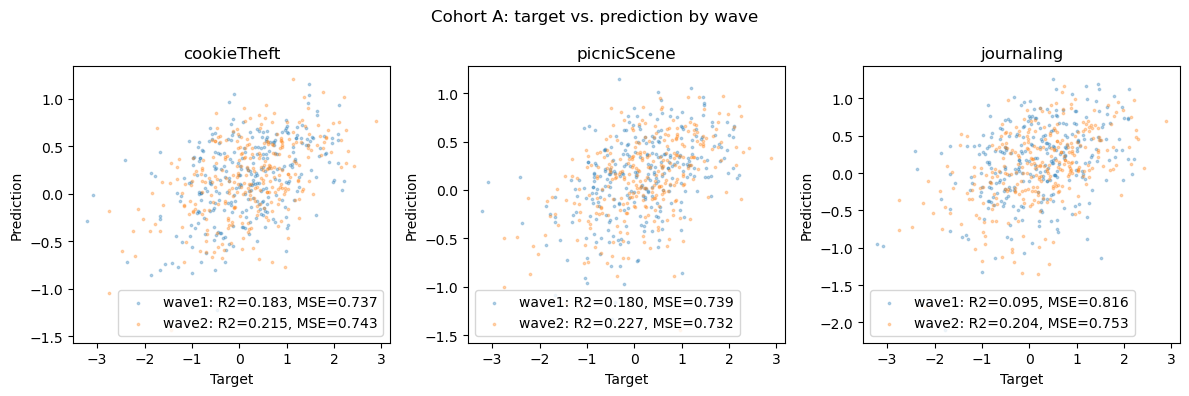

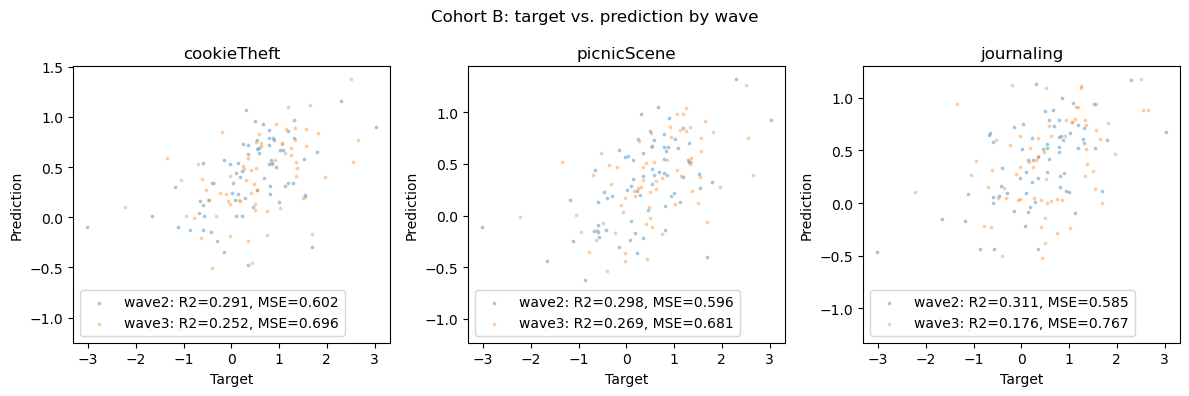

In [73]:
def plot_target_vs_prediction_scatter(longitudinal, label, wave_a, wave_b):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for task, ax in zip(['cookieTheft', 'picnicScene', 'journaling'], axes):
        for wave in [wave_a, wave_b]:
            data_here = longitudinal[
                [(wave, target, 'target'), (wave, target, task)]
            ].copy().dropna()
            r2 = r2_score(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
            )
            mse = mean_squared_error(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
            )
            ax.scatter(
                data_here[(wave, target, 'target')],
                data_here[(wave, target, task)],
                alpha=0.3,
                label=f"{wave}: R2={r2:.3f}, MSE={mse:.3f}",
                s=3,
            )
        ax.set_title(task)
        ax.legend()
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')
    fig.suptitle(f'Cohort {label}: target vs. prediction by wave')
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_target_vs_prediction_scatter(longitudinal_by_cohort[label], label, wave_a, wave_b)

## MDC — bootstrap CIs

In [75]:
import pingouin as pg


def _icc31(a, b) -> float:
    """
    ICC(3,1) via pingouin, mirroring calculate_test_retest's long-format setup.
    `a` and `b` are paired vectors (e.g. wave_a and wave_b ratings).
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(a)
    if n < 2:
        return np.nan
    long_df = pd.DataFrame({
        "score": np.concatenate([a, b]),
        "time": np.concatenate([np.full(n, "a"), np.full(n, "b")]),
        "participant": np.concatenate([np.arange(n), np.arange(n)]),
    })
    try:
        icc_result = pg.intraclass_corr(
            data=long_df, targets="participant", raters="time",
            ratings="score", nan_policy="omit",
        )
        return icc_result.loc[icc_result["Type"] == "ICC3", "ICC"].values[0]
    except Exception:
        return np.nan


def _icc31(a: np.ndarray, b: np.ndarray) -> float:
    """
    ICC(3,1): two-way mixed, single rater, consistency.
    Computed from one-way-within-subjects ANOVA with k=2 ratings per subject.
        ICC(3,1) = (MS_between - MS_within) / (MS_between + (k-1) * MS_within)
    Returns np.nan if degenerate.
    Much faster than pg version above
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    n = len(a)
    if n < 2:
        return np.nan
    k = 2
    subj_means = (a + b) / 2.0
    grand_mean = (a.sum() + b.sum()) / (2 * n)
    ss_between = k * np.sum((subj_means - grand_mean) ** 2)
    ss_within = np.sum((a - subj_means) ** 2) + np.sum((b - subj_means) ** 2)
    ms_between = ss_between / (n - 1)
    ms_within = ss_within / (n * (k - 1))
    denom = ms_between + (k - 1) * ms_within
    if not np.isfinite(denom) or denom <= 0:
        return np.nan
    return (ms_between - ms_within) / denom


def calculate_mdc_with_bootstrap_CI(
    df: pd.DataFrame,
    domain: str = "language",
    tasks=("cookieTheft", "picnicScene", "journaling",
           "avg_speech_prediction", "avg_cookieTheft_picnicScene"),
    waves=("wave1", "wave2"),
    z: float = 1.96,
    n_boot: int = 2000,
    ci: float = 0.95,
    random_state: int | None = 0,
) -> pd.DataFrame:
    """
    Estimate MDC with nonparametric bootstrap CIs.

    Bootstrap resamples subjects (rows) with replacement from the per-task
    complete-case frame, recomputing Var(C), lambda, and the MDCs on each
    replicate. The cognitive MDC is computed on the SAME bootstrap sample
    (using the x1, x2 columns of each task's frame), so that speech-latent
    and cognitive MDCs are paired per task per replicate.

    Also bootstraps:
      - R^2 per task (average of per-wave sk_metrics.r2_score(x, y))
      - ICC(3,1) per task on (y1, y2), via pingouin
      - ICC(3,1) for cognition on the target pair (x1, x2), via pingouin
    Returns percentile CIs at the requested level.
    """
    wave_a, wave_b = waves
    alpha = (1 - ci) / 2
    rng = np.random.default_rng(random_state)

    x1 = df[(wave_a, domain, "target")]
    x2 = df[(wave_b, domain, "target")]
    target_pair = pd.concat({"x1": x1, "x2": x2}, axis=1).dropna()
    if len(target_pair) < 3:
        raise ValueError("Not enough complete target pairs.")

    # Build per-task complete-case frames once
    task_frames = {}
    for task in tasks:
        y1 = df[(wave_a, domain, task)]
        y2 = df[(wave_b, domain, task)]
        tmp = pd.concat({"x1": x1, "x2": x2, "y1": y1, "y2": y2}, axis=1).dropna()
        if len(tmp) < 3:
            raise ValueError(f"Not enough complete cases for task {task!r}.")
        task_frames[task] = tmp

    # Point estimates
    var_c_hat = target_pair["x1"].cov(target_pair["x2"])
    reliability_target = target_pair["x1"].corr(target_pair["x2"])
    var_y_obs = np.mean([target_pair["x1"].var(), target_pair["x2"].var()])
    if not np.isfinite(var_c_hat) or var_c_hat <= 0:
        raise ValueError(f"Var(C) non-positive ({var_c_hat:.4f}).")
    mdc_cognitive = z * np.sqrt(2 * var_y_obs * (1 - reliability_target))
    icc_cognitive_hat = _icc31(target_pair["x1"].values, target_pair["x2"].values)

    rows = []
    for task, tmp in task_frames.items():
        n = len(tmp)
        regression_r2 = np.mean([
            sk_metrics.r2_score(tmp["x1"], tmp["y1"]),
            sk_metrics.r2_score(tmp["x2"], tmp["y2"]),
        ])
        regression_mse = np.mean([
            sk_metrics.mean_squared_error(tmp["x1"], tmp["y1"]),
            sk_metrics.mean_squared_error(tmp["x2"], tmp["y2"]),
        ])
        cov_y1_x1 = tmp["y1"].cov(tmp["x1"])
        cov_y2_x2 = tmp["y2"].cov(tmp["x2"])
        lambda_hat = np.mean([cov_y1_x1, cov_y2_x2]) / var_c_hat

        delta_yhat = tmp["y2"] - tmp["y1"]
        var_delta_yhat = delta_yhat.var()
        sd_delta_yhat = delta_yhat.std()
        sigma_epsilon_sq_hat = var_delta_yhat / 2.0
        mdc_speech_pred = z * sd_delta_yhat
        mdc_speech_latent = mdc_speech_pred / np.abs(lambda_hat)

        icc_hat = _icc31(tmp["y1"].values, tmp["y2"].values)

        rows.append({
            "task": task, "n": n,
            "regression_r2": regression_r2,
            "regression_mse": regression_mse,
            "var_c_hat": var_c_hat,
            "var_y_obs": var_y_obs,
            "target_reliability_hat": reliability_target,
            "lambda_hat": lambda_hat,
            "var_delta_yhat": var_delta_yhat,
            "sd_delta_yhat": sd_delta_yhat,
            "sigma_epsilon_sq_hat": sigma_epsilon_sq_hat,
            "sigma_epsilon_hat": np.sqrt(sigma_epsilon_sq_hat),
            "mdc_speech_pred": mdc_speech_pred,
            "mdc_speech_latent": mdc_speech_latent,
            "mdc_cognitive": mdc_cognitive,
            "icc_hat": icc_hat,
            "icc_cognitive_hat": icc_cognitive_hat,
        })

    # --- Bootstrap ---
    boot_speech_pred   = {t: np.empty(n_boot) for t in tasks}
    boot_speech_latent = {t: np.empty(n_boot) for t in tasks}
    boot_cognitive     = {t: np.empty(n_boot) for t in ['all'] + list(tasks)}
    boot_r2            = {t: np.empty(n_boot) for t in tasks}
    boot_icc           = {t: np.empty(n_boot) for t in tasks}
    boot_icc_cognitive = np.empty(n_boot)
    n_target = len(target_pair)

    task_n = {t: len(f) for t, f in task_frames.items()}

    for b in range(n_boot):
        #if b % (n_boot // 10) == 0:
        #    print(f"Bootstrap {b+1}/{n_boot}...", end="", flush=True)

        # Cognitive MDC and ICC on a resample of the full target pair
        idx_t = rng.integers(0, n_target, n_target)
        tp_b = target_pair.iloc[idx_t]
        var_c_b = tp_b["x1"].cov(tp_b["x2"])
        rel_b = tp_b["x1"].corr(tp_b["x2"])
        var_y_b = np.mean([tp_b["x1"].var(), tp_b["x2"].var()])
        if np.isfinite(var_c_b) and var_c_b > 0 and np.isfinite(rel_b):
            boot_cognitive['all'][b] = z * np.sqrt(2 * var_y_b * max(1 - rel_b, 0))
        else:
            boot_cognitive['all'][b] = np.nan
        boot_icc_cognitive[b] = _icc31(tp_b["x1"].values, tp_b["x2"].values)

        for task, frame in task_frames.items():
            nn = task_n[task]
            idx = rng.integers(0, nn, nn)
            tb = frame.iloc[idx]

            vc  = tb["x1"].cov(tb["x2"])
            rel = tb["x1"].corr(tb["x2"])
            var_y_b = np.mean([tb["x1"].var(), tb["x2"].var()])

            if np.isfinite(vc) and vc > 0 and np.isfinite(rel):
                boot_cognitive[task][b] = z * np.sqrt(2 * var_y_b * max(1 - rel, 0))
            else:
                boot_cognitive[task][b] = np.nan

            # R^2 per wave averaged on the bootstrap sample
            try:
                r2_b = np.mean([
                    sk_metrics.r2_score(tb["x1"], tb["y1"]),
                    sk_metrics.r2_score(tb["x2"], tb["y2"]),
                ])
            except Exception:
                r2_b = np.nan
            boot_r2[task][b] = r2_b

            # ICC(3,1) on the speech predictions
            boot_icc[task][b] = _icc31(tb["y1"].values, tb["y2"].values)

            if not np.isfinite(vc) or vc <= 0:
                boot_speech_pred[task][b] = np.nan
                boot_speech_latent[task][b] = np.nan
                continue
            lam = np.mean([tb["y1"].cov(tb["x1"]), tb["y2"].cov(tb["x2"])]) / vc
            sd_d = (tb["y2"] - tb["y1"]).std()
            mp = z * sd_d
            boot_speech_pred[task][b] = mp
            boot_speech_latent[task][b] = (
                mp / np.abs(lam) if np.isfinite(lam) and not np.isclose(lam, 0) else np.nan
            )

    lo_q, hi_q = alpha, 1 - alpha

    icc_cog_lo, icc_cog_hi = np.nanpercentile(boot_icc_cognitive, [100 * lo_q, 100 * hi_q])

    for row in rows:
        t = row["task"]
        sp = boot_speech_pred[t]
        sl = boot_speech_latent[t]
        cg = boot_cognitive[t]
        r2 = boot_r2[t]
        ic = boot_icc[t]

        mdc_speech_pred_low, mdc_speech_pred_high = np.nanpercentile(sp, [100*lo_q, 100*hi_q])
        row["mdc_speech_pred_text"] = (
            f"{row['mdc_speech_pred']:.2f} "
            f"({mdc_speech_pred_low:.2f}-{mdc_speech_pred_high:.2f})"
        )

        mdc_speech_latent_low, mdc_speech_latent_high = np.nanpercentile(sl, [100*lo_q, 100*hi_q])
        row["mdc_speech_latent_text"] = (
            f"{row['mdc_speech_latent']:.2f} "
            f"({mdc_speech_latent_low:.2f}-{mdc_speech_latent_high:.2f})"
        )

        mdc_cognitive_low, mdc_cognitive_high = np.nanpercentile(cg, [100*lo_q, 100*hi_q])
        row["mdc_cognitive_text"] = (
            f"{row['mdc_cognitive']:.2f} "
            f"({mdc_cognitive_low:.2f}-{mdc_cognitive_high:.2f})"
        )

        r2_low, r2_high = np.nanpercentile(r2, [100*lo_q, 100*hi_q])
        row["regression_r2_text"] = (
            f"{row['regression_r2']:.2f} ({r2_low:.2f}-{r2_high:.2f})"
        )

        icc_low, icc_high = np.nanpercentile(ic, [100*lo_q, 100*hi_q])
        row["icc_text"] = (
            f"{row['icc_hat']:.2f} ({icc_low:.2f}-{icc_high:.2f})"
        )

        row["icc_cognitive_text"] = (
            f"{row['icc_cognitive_hat']:.2f} ({icc_cog_lo:.2f}-{icc_cog_hi:.2f})"
        )

        row['mdc_speech_latent_bootstrap_dist'] = sl
        row['mdc_cognition_bootstrap_dist_task']     = cg
        row['mdc_speech_pred_bootstrap_dist']   = sp
        row['mdc_cognition_bootstrap_dist_all'] = boot_cognitive['all']


    return pd.DataFrame(rows).set_index("task")



mdc_results_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) — running bootstrap ===')
    mdc_results_by_cohort[label] = calculate_mdc_with_bootstrap_CI(
        longitudinal_by_cohort[label], domain=target,
        waves=(wave_a, wave_b), n_boot=n_bootsrap_samples,
    )
    results[label]['mdc'] = mdc_results_by_cohort[label]

mdc_results_by_cohort['A']


=== Cohort A (wave1 ↔ wave2) — running bootstrap ===

=== Cohort B (wave2 ↔ wave3) — running bootstrap ===


,n,regression_r2,regression_mse,var_c_hat,var_y_obs,target_reliability_hat,lambda_hat,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,...,mdc_speech_pred_text,mdc_speech_latent_text,mdc_cognitive_text,regression_r2_text,icc_text,icc_cognitive_text,mdc_speech_latent_bootstrap_dist,mdc_cognition_bootstrap_dist_task,mdc_speech_pred_bootstrap_dist,mdc_cognition_bootstrap_dist_all
task,,,,,,,,,,,,,,,,,,,,,
cookieTheft,279,0.184728,0.710887,0.599115,0.875387,0.684498,0.274956,0.111472,0.333875,0.055736,...,0.65 (0.59-0.71),2.38 (1.90-3.04),1.46 (1.28-1.65),0.18 (0.11-0.24),0.67 (0.59-0.73),0.68 (0.60-0.75),"[2.819074615016348, 2.5820319293540455, 2.4007...","[1.4127969444009103, 1.4818707905424817, 1.276...","[0.6063116218251082, 0.6290964153911595, 0.632...","[1.4258544456413595, 1.567840223999432, 1.4457..."
picnicScene,279,0.198728,0.698544,0.599115,0.875387,0.684498,0.296779,0.094301,0.307085,0.047151,...,0.60 (0.55-0.65),2.03 (1.62-2.53),1.46 (1.29-1.64),0.20 (0.12-0.26),0.74 (0.67-0.78),0.68 (0.60-0.75),"[1.5954367502429276, 2.563437303914538, 1.9651...","[1.5138338343980513, 1.438807975799595, 1.4318...","[0.5910741211078158, 0.5863515123328676, 0.583...","[1.4258544456413595, 1.567840223999432, 1.4457..."
journaling,279,0.129649,0.758424,0.599115,0.875387,0.684498,0.314314,0.233495,0.483213,0.116747,...,0.95 (0.84-1.04),3.01 (2.38-3.76),1.46 (1.29-1.64),0.13 (0.04-0.21),0.54 (0.47-0.61),0.68 (0.60-0.75),"[3.0750350950349636, 2.72983072064864, 2.68785...","[1.3468731672195189, 1.4730716670794646, 1.474...","[0.961553261872706, 0.9599217879310786, 0.9007...","[1.4258544456413595, 1.567840223999432, 1.4457..."
avg_speech_prediction,279,0.225156,0.675441,0.599115,0.875387,0.684498,0.295350,0.065863,0.256637,0.032931,...,0.50 (0.46-0.54),1.70 (1.40-2.08),1.46 (1.28-1.63),0.23 (0.16-0.28),0.78 (0.74-0.82),0.68 (0.60-0.75),"[1.71157561554357, 1.9002057377550226, 1.59677...","[1.4659080658772456, 1.3589660019649135, 1.607...","[0.5292947547252972, 0.49443427612575275, 0.49...","[1.4258544456413595, 1.567840223999432, 1.4457..."
avg_cookieTheft_picnicScene,279,0.216004,0.683514,0.599115,0.875387,0.684498,0.285868,0.063877,0.252740,0.031939,...,0.50 (0.46-0.54),1.73 (1.42-2.16),1.46 (1.28-1.63),0.22 (0.14-0.27),0.79 (0.74-0.83),0.68 (0.60-0.75),"[1.9859760843727001, 1.521266910844544, 1.4753...","[1.3757583053897047, 1.6066873393329444, 1.642...","[0.5181801435378766, 0.4867117456848893, 0.464...","[1.4258544456413595, 1.567840223999432, 1.4457..."


In [76]:
mdc_results_by_cohort['B']

,n,regression_r2,regression_mse,var_c_hat,var_y_obs,target_reliability_hat,lambda_hat,var_delta_yhat,sd_delta_yhat,sigma_epsilon_sq_hat,...,mdc_speech_pred_text,mdc_speech_latent_text,mdc_cognitive_text,regression_r2_text,icc_text,icc_cognitive_text,mdc_speech_latent_bootstrap_dist,mdc_cognition_bootstrap_dist_task,mdc_speech_pred_bootstrap_dist,mdc_cognition_bootstrap_dist_all
task,,,,,,,,,,,,,,,,,,,,,
cookieTheft,69,0.273203,0.651038,0.652159,0.907882,0.718922,0.329113,0.059672,0.244279,0.029836,...,0.48 (0.37-0.57),1.45 (0.95-2.21),1.40 (1.02-1.71),0.27 (0.10-0.39),0.83 (0.72-0.90),0.71 (0.57-0.81),"[1.5850898042575308, 0.9526115881181932, 1.910...","[1.3836179088153275, 1.2730710051946823, 1.397...","[0.4004516635617524, 0.42734702841785965, 0.53...","[1.0971789988395932, 1.359433660728746, 1.3768..."
picnicScene,69,0.286686,0.638872,0.652159,0.907882,0.718922,0.363738,0.050351,0.224389,0.025175,...,0.44 (0.36-0.50),1.21 (0.83-1.71),1.40 (1.03-1.71),0.29 (0.09-0.42),0.87 (0.80-0.92),0.71 (0.57-0.81),"[1.0614973574689721, 1.0688827630784474, 1.557...","[1.2459839425423802, 1.2048280658303565, 1.026...","[0.39574050299565716, 0.38131530662988034, 0.5...","[1.0971789988395932, 1.359433660728746, 1.3768..."
journaling,69,0.244814,0.678173,0.652159,0.907882,0.718922,0.330065,0.091640,0.302720,0.045820,...,0.59 (0.47-0.72),1.80 (1.22-2.82),1.40 (1.04-1.70),0.24 (0.05-0.37),0.77 (0.60-0.87),0.71 (0.57-0.81),"[2.4541211839481796, 2.6768803149608114, 2.531...","[1.2208723052639596, 1.843831143684197, 1.3357...","[0.5638359767572467, 0.7624208280039138, 0.653...","[1.0971789988395932, 1.359433660728746, 1.3768..."
avg_speech_prediction,69,0.296157,0.631017,0.652159,0.907882,0.718922,0.340972,0.030146,0.173626,0.015073,...,0.34 (0.25-0.42),1.00 (0.64-1.49),1.40 (1.04-1.71),0.30 (0.13-0.40),0.91 (0.84-0.95),0.71 (0.57-0.81),"[0.833713049862832, 1.0974648201726966, 0.8939...","[1.2540136591104205, 1.4085429726416179, 1.358...","[0.30813900240540354, 0.36635723166988887, 0.3...","[1.0971789988395932, 1.359433660728746, 1.3768..."
avg_cookieTheft_picnicScene,69,0.295135,0.631310,0.652159,0.907882,0.718922,0.346426,0.033471,0.182950,0.016735,...,0.36 (0.28-0.42),1.04 (0.67-1.54),1.40 (1.05-1.70),0.30 (0.13-0.42),0.90 (0.83-0.94),0.71 (0.57-0.81),"[0.9119789621098385, 0.9844822169349408, 0.903...","[1.2601000252117573, 1.4979007858417186, 1.329...","[0.2995444585528123, 0.33962499639601507, 0.34...","[1.0971789988395932, 1.359433660728746, 1.3768..."


## Bootstrap test: speech MDC − cognitive MDC

In [77]:
def bootstrap_diff_speech_minus_cognitive_significance_test(
    results: pd.DataFrame, ci: float = 0.95,
) -> pd.DataFrame:
    alpha = (1 - ci) / 2
    out = []
    for task, row in results.iterrows():
        a = np.asarray(row["mdc_speech_latent_bootstrap_dist"], dtype=float)
        c = np.asarray(row["mdc_cognition_bootstrap_dist_task"], dtype=float)
        mask = np.isfinite(a) & np.isfinite(c)
        d = a[mask] - c[mask]
        lo, hi = np.nanpercentile(d, [100*alpha, 100*(1-alpha)])
        out.append({
            "task": task,
            "n_pairs": len(d),
            "mean_diff": d.mean(),
            "median_diff": np.median(d),
            "ci_low": lo,
            "ci_high": hi,
            "prop_speech_worse": np.mean(d > 0),
            "excludes_zero": lo > 0 or hi < 0,
        })
    return pd.DataFrame(out).set_index("task")


bootstrap_test_by_cohort = {}
for label, _, _ in COHORTS:
    bootstrap_test_by_cohort[label] = bootstrap_diff_speech_minus_cognitive_significance_test(
        mdc_results_by_cohort[label]
    )
    print(f'\n=== Cohort {label} ===')
    display(bootstrap_test_by_cohort[label])
    results[label]['bootstrap_test'] = bootstrap_test_by_cohort[label]


=== Cohort A ===


,n_pairs,mean_diff,median_diff,ci_low,ci_high,prop_speech_worse,excludes_zero
task,,,,,,,
cookieTheft,1000,0.963517,0.933944,0.358131,1.690520,1.000,True
picnicScene,1000,0.589740,0.584346,0.063182,1.156796,0.982,True
journaling,1000,1.552754,1.537440,0.812848,2.392725,1.000,True
avg_speech_prediction,1000,0.260271,0.247199,-0.161557,0.729888,0.877,False
avg_cookieTheft_picnicScene,1000,0.299982,0.297256,-0.159823,0.779677,0.891,False



=== Cohort B ===


,n_pairs,mean_diff,median_diff,ci_low,ci_high,prop_speech_worse,excludes_zero
task,,,,,,,
cookieTheft,1000,0.106018,0.073280,-0.517122,0.961016,0.573,False
picnicScene,1000,-0.154260,-0.172497,-0.649545,0.421783,0.258,False
journaling,1000,0.489505,0.432964,-0.275273,1.516284,0.876,False
avg_speech_prediction,1000,-0.361539,-0.369812,-0.866862,0.236535,0.102,False
avg_cookieTheft_picnicScene,1000,-0.319703,-0.335146,-0.793142,0.218485,0.125,False


## Forest plot — one PDF per cohort

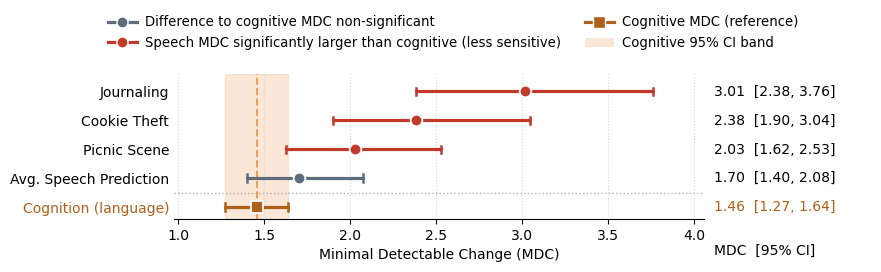

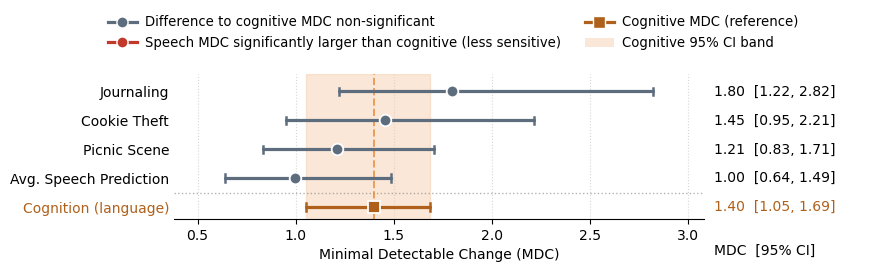

In [78]:
task_replacement = {
    'journaling': 'Journaling',
    'cookieTheft': 'Cookie Theft',
    'picnicScene': 'Picnic Scene',
    'avg_speech_prediction': 'Avg. Speech Prediction',
}


def ci(dist, alpha=0.05):
    lo, hi = np.percentile(dist, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi


def classify_by_ci(speech_lo, speech_hi, cog_lo, cog_hi):
    """Compare a speech CI to the cognitive CI band."""
    if speech_hi < cog_lo:
        return "better"
    if speech_lo > cog_hi:
        return "worse"
    return "overlap"


def make_classifier(bootstrap_test_res):
    """Closure over a cohort-specific bootstrap test dataframe."""
    def classify(task):
        if bootstrap_test_res.loc[task, 'excludes_zero']:
            return 'worse'
        else:
            return 'overlap'
    return classify


def forest_plot(df, classify_fn, title_suffix='', figsize=None, xlim=None):
    tasks = df.index.tolist()
    n = len(tasks)

    speech_vals = df["mdc_speech_latent"].values.astype(float)
    speech_ci = np.array([ci(d) for d in df["mdc_speech_latent_bootstrap_dist"]])

    cog_val = float(df["mdc_cognitive"].iloc[0])
    cog_lo, cog_hi = ci(df["mdc_cognition_bootstrap_dist_all"].iloc[0])

    # Sort speech tasks so smallest MDC ends up closest to the cognition row.
    order = np.argsort(speech_vals)[::-1]
    tasks = [tasks[i] for i in order]
    tasks_renamed = [task_replacement.get(t, t) for t in tasks]
    speech_vals = speech_vals[order]
    speech_ci = speech_ci[order]

    C = {
        "better":   "#1E8449",
        "overlap":  "#5D6D7E",
        "worse":    "#C0392B",
        "cog":      "#E67E22",
        "cog_dark": "#AF601A",
        "cog_band": "#F5CBA7",
    }

    if figsize is None:
        figsize = (11, max(4.5, 0.6 * (n + 1) + 3.0))
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 2,
        width_ratios=[3.3, 1.0],
        height_ratios=[0.15, 1],
        hspace=0.5, wspace=0.02,
        figure=fig,
    )
    ax = fig.add_subplot(gs[1, 0])
    ax_tbl = fig.add_subplot(gs[1, 1], sharey=ax)
    ax_leg = fig.add_subplot(gs[0, :])
    ax_leg.axis("off")

    # Rows 0..n-1 = speech tasks (top). Row n = cognition (bottom).
    y_speech = np.arange(n)
    y_cog = n

    # Reference band + line for cognitive CI (spans full plot).
    ax.axvspan(cog_lo, cog_hi, color=C["cog_band"], alpha=0.45, zorder=1)
    ax.axvline(cog_val, color=C["cog"], linestyle="--", linewidth=1.4,
               alpha=0.7, zorder=2)

    # Separator between speech tasks and cognition reference row.
    ax.axhline(n - 0.5, color="gray", linestyle=":", linewidth=1, alpha=0.6,
               zorder=1)

    # Speech CIs + point estimates
    for yi, val, (lo, hi), task in zip(y_speech, speech_vals, speech_ci, tasks):
        color = C[classify_fn(task)]
        ax.plot([lo, hi], [yi, yi], color=color, linewidth=2.3,
                solid_capstyle="round", zorder=3)
        ax.plot([lo, lo], [yi - 0.13, yi + 0.13], color=color, linewidth=1.8, zorder=3)
        ax.plot([hi, hi], [yi - 0.13, yi + 0.13], color=color, linewidth=1.8, zorder=3)
        ax.scatter([val], [yi], s=70, color=color,
                   edgecolor="white", linewidth=1.3, zorder=4)

    # Cognition row — square marker in orange to distinguish from speech circles
    ax.plot([cog_lo, cog_hi], [y_cog, y_cog], color=C["cog_dark"],
            linewidth=2.3, solid_capstyle="round", zorder=3)
    ax.plot([cog_lo, cog_lo], [y_cog - 0.13, y_cog + 0.13],
            color=C["cog_dark"], linewidth=1.8, zorder=3)
    ax.plot([cog_hi, cog_hi], [y_cog - 0.13, y_cog + 0.13],
            color=C["cog_dark"], linewidth=1.8, zorder=3)
    ax.scatter([cog_val], [y_cog], s=70, color=C["cog_dark"], marker="s",
               edgecolor="white", linewidth=1.3, zorder=4)

    # Y-axis: task labels + cognition label
    ax.set_yticks(list(y_speech) + [y_cog])
    ax.set_yticklabels(tasks_renamed + [f"Cognition ({target})"])
    yticklabels = ax.get_yticklabels()
    yticklabels[-1].set_color(C["cog_dark"])

    ax.set_ylim(-0.6, n + 0.4)
    ax.invert_yaxis()

    if xlim is None:
        all_lo = min(speech_ci[:, 0].min(), cog_lo)
        all_hi = max(speech_ci[:, 1].max(), cog_hi)
        pad = 0.12 * (all_hi - all_lo)
        xlim = (max(0, all_lo - pad), all_hi + pad)
    ax.set_xlim(*xlim)
    ax.set_xlabel("Minimal Detectable Change (MDC)")
    if title_suffix:
        ax.set_title(title_suffix, loc='left', fontsize=10)

    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)

    # Numeric column
    ax_tbl.set_xlim(0, 1)
    ax_tbl.set_ylim(ax.get_ylim())
    ax_tbl.axis("off")
    ax_tbl.text(0.02, y_cog + 1.5, "MDC  [95% CI]",
                fontsize=10, fontweight="normal", va="center", ha="left")
    for yi, val, (lo, hi) in zip(y_speech, speech_vals, speech_ci):
        ax_tbl.text(0.02, yi, f"{val:.2f}  [{lo:.2f}, {hi:.2f}]",
                    fontsize=10, va="center", ha="left")
    ax_tbl.text(0.02, y_cog,
                f"{cog_val:.2f}  [{cog_lo:.2f}, {cog_hi:.2f}]",
                fontsize=10, va="center", ha="left",
                fontweight="normal", color=C["cog_dark"])

    # Legend strip on top
    legend_elements = [
        Line2D([0], [0], marker="o", color=C["overlap"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Difference to cognitive MDC non-significant"),
        Line2D([0], [0], marker="o", color=C["worse"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Speech MDC significantly larger than cognitive (less sensitive)"),
        Line2D([0], [0], marker="s", color=C["cog_dark"], lw=2.3, markersize=8,
               markeredgecolor="white",
               label="Cognitive MDC (reference)"),
        Patch(facecolor=C["cog_band"], alpha=0.45, label="Cognitive 95% CI band"),
    ]
    ax_leg.legend(
        handles=legend_elements, frameon=False, fontsize=9.5,
        loc="center",
        bbox_to_anchor=[0.4, 0],
        ncol=2,
        handlelength=2.2, columnspacing=1.8, handletextpad=0.6,
    )

    return fig, ax


for label, wave_a, wave_b in COHORTS:
    classify_fn = make_classifier(bootstrap_test_by_cohort[label])
    df_for_plot = mdc_results_by_cohort[label].query(
        "task != 'avg_cookieTheft_picnicScene'"
    )
    fig, ax = forest_plot(
        df_for_plot, classify_fn,
        #title_suffix=f'Cohort {label}: {wave_a} ↔ {wave_b}',
        figsize=(9, 2.7),
    )
    plt.savefig(f"plots/MDC_{target}_{VERSION}_cohort{label}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Bootstrap test — LaTeX tables (one per cohort)

In [79]:
for label, wave_a, wave_b in COHORTS:
    bootstrap_test_res = bootstrap_test_by_cohort[label]
    bootstrap_test_beautified = bootstrap_test_res.copy().loc[
        ~bootstrap_test_res.index.str.startswith("avg_cookieTheft_picnicScene")
    ].copy()
    bootstrap_test_beautified['ci'] = bootstrap_test_beautified.apply(
        lambda row: f"{row['ci_low']:.2f} -- {row['ci_high']:.2f}", axis=1,
    )
    bootstrap_test_beautified['prop_speech_worse'] = bootstrap_test_beautified['prop_speech_worse'].apply(lambda frac: f"{frac:.1%}")
    bootstrap_test_beautified = bootstrap_test_beautified[
        ['mean_diff', 'ci', 'prop_speech_worse', 'excludes_zero']
    ].rename(
        columns={
            'mean_diff': 'Mean Diff',
            'ci_low': '95% CI Low',
            'ci_high': '95% CI High',
            'ci': '95% CI',
            'prop_speech_worse': '\\shortstack[l]{% Speech\\\\MDC larger}',
            'excludes_zero': '\\shortstack[l]{Significant\\\\difference}',
        },
        index={t: task_replacement.get(t, t) for t in bootstrap_test_beautified.index},
    )
    bootstrap_test_beautified.index.name = None

    bootstrap_test_rest_latex = bootstrap_test_beautified.to_latex(
        float_format="%.2f",
        column_format="lcccccc",
        label=f"tab:mdc_bootstrap_test_rest_cohort{label}",
        caption=(
            f"Bootstrap test results assessing if the speech-based MDC is significantly larger than cognitive MDC on Cohort {label}. We report the mean difference in MDCs across {n_bootsrap_samples} bootstrap replicates, the 95% CI of the difference, and the proportion of replicates where speech MDC is larger (worse) than cognitive MDC."
        ),
    ).replace("%", "\\%")
    print(f'\n% === MDC stats results: Cohort {label} ({now()}) ===')
    print(bootstrap_test_rest_latex)


% === MDC stats results: Cohort A (2026-06-02 13:14) ===
\begin{table}
\caption{Bootstrap test results assessing if the speech-based MDC is significantly larger than cognitive MDC on Cohort A. We report the mean difference in MDCs across 1000 bootstrap replicates, the 95\% CI of the difference, and the proportion of replicates where speech MDC is larger (worse) than cognitive MDC.}
\label{tab:mdc_bootstrap_test_rest_cohortA}
\begin{tabular}{lcccccc}
\toprule
 & Mean Diff & 95\% CI & \shortstack[l]{\% Speech\\MDC larger} & \shortstack[l]{Significant\\difference} \\
\midrule
Cookie Theft & 0.96 & 0.36 -- 1.69 & 100.0\% & True \\
Picnic Scene & 0.59 & 0.06 -- 1.16 & 98.2\% & True \\
Journaling & 1.55 & 0.81 -- 2.39 & 100.0\% & True \\
Avg. Speech Prediction & 0.26 & -0.16 -- 0.73 & 87.7\% & False \\
\bottomrule
\end{tabular}
\end{table}


% === MDC stats results: Cohort B (2026-06-02 13:14) ===
\begin{table}
\caption{Bootstrap test results assessing if the speech-based MDC is significant

## SEM — four-indicator measurement model

In [81]:
def fit_four_indicator_sem(dat, model_type="full"):
    """
    Fit one of seven measurement models to four indicators per participant
    (y1, y2, hat_y1, hat_y2).

    Baseline ("full") assumes:
      - time-invariant attenuation lam on hat_y,
      - stable speaker bias b, orthogonal to C, with unit loadings on hat_y,
      - stationary residual variances (v1 for y, ve for hat_y),
      - independent residuals across waves.
    """
    specs = {
        "full": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "no_attenuation": """
            c =~ 1*y1 + 1*y2 + 1*hat_y1 + 1*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "no_beta": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
        """,
        "no_attenuation_no_beta": """
            c =~ 1*y1 + 1*y2 + 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
        """,
        "correlated_hat_residuals": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            hat_y1 ~~ rh*hat_y2
            c ~~ c
        """,
        "free_hat_resid_by_wave": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v1*y2
            hat_y1 ~~ ve1*hat_y1
            hat_y2 ~~ ve2*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
        "free_y_resid_by_wave": """
            c =~ 1*y1 + 1*y2 + lam*hat_y1 + lam*hat_y2
            b =~ 1*hat_y1 + 1*hat_y2
            y1 ~~ v1*y1
            y2 ~~ v2*y2
            hat_y1 ~~ ve*hat_y1
            hat_y2 ~~ ve*hat_y2
            c ~~ c
            b ~~ b
            c ~~ 0*b
        """,
    }

    if model_type not in specs:
        raise ValueError(f"Unknown model_type: {model_type}")

    sem_desc = specs[model_type]
    try:
        model = Model(sem_desc, mimic_lavaan=True)
        model.fit(dat)
        fit_stats = calc_stats(model)

        # manual srmr calculation, checked against R's lavaan implementation
        obs_vars = model.vars['observed']
        S = dat[obs_vars].cov().values
        n = dat.shape[0]
        S = S * (n - 1) / n  # match lavaan's ML sample cov
        Sigma, _ = model.calc_sigma()
        inv_std = np.diag(1 / np.sqrt(np.diag(S)))
        S_std = inv_std @ S @ inv_std
        Sigma_std = inv_std @ Sigma @ inv_std
        R = S_std - Sigma_std
        idx = np.tril_indices_from(R)
        residuals = R[idx]
        srmr = np.sqrt(np.mean(residuals**2))
        fit_stats["SRMR"] = srmr

        fit_stats = fit_stats.T if hasattr(fit_stats, "T") else fit_stats
        return {
            "model_type": model_type,
            "model_syntax": sem_desc,
            "parameter_estimates": model.inspect(),
            "fit_stats": fit_stats,
        }
    except Exception as e:
        print(f"error fitting {model_type}:", str(e))
        return {"model_type": model_type, "model_syntax": sem_desc, "error": str(e)}


def lr_test(restricted, unrestricted):
    """
    Chi-square difference (likelihood-ratio) test for nested SEM models.
    """
    if "error" in restricted or "error" in unrestricted:
        return {"delta_chi2": np.nan, "delta_df": np.nan, "p_value": np.nan}
    chi2_r = float(restricted["fit_stats"].loc["chi2", "Value"])
    chi2_u = float(unrestricted["fit_stats"].loc["chi2", "Value"])
    df_r   = float(restricted["fit_stats"].loc["DoF",  "Value"])
    df_u   = float(unrestricted["fit_stats"].loc["DoF",  "Value"])
    delta_chi2 = chi2_r - chi2_u
    delta_df   = df_r - df_u
    p_value    = 1 - chi2_dist.cdf(delta_chi2, delta_df) if delta_df > 0 else np.nan
    return {"delta_chi2": delta_chi2, "delta_df": int(delta_df), "p_value": p_value}


model_names = [
    "full",
    "no_attenuation",
    "no_beta",
    "no_attenuation_no_beta",
    #"correlated_hat_residuals",
    "free_hat_resid_by_wave",
    "free_y_resid_by_wave",
]

lr_pairs = [
    ("no_attenuation",          "full"),
    ("no_beta",                 "full"),
    ("no_attenuation_no_beta",  "full"),
    ("full", "free_hat_resid_by_wave"),
    ("full", "free_y_resid_by_wave"),
]

fit_stats_to_report = ["chi2", "chi2 p-value", "DoF", "CFI", "TLI", 'SRMR']


def run_sem_for_cohort(longitudinal, wave_a, wave_b, sem_tasks, target):
    target_a_col = (wave_a, target, 'target')
    target_b_col = (wave_b, target, 'target')
    task_fit_dfs = []
    task_lr_dfs = []

    for task in sem_tasks:
        df_here = longitudinal[[
            target_a_col, target_b_col,
            (wave_a, target, task), (wave_b, target, task),
        ]].dropna().copy()
        df_here.columns = ['y1', 'y2', 'hat_y1', 'hat_y2']

        models = {name: fit_four_indicator_sem(df_here, name) for name in model_names}

        fit_rows = {}
        for name, m in models.items():
            if 'error' in m:
                fit_rows[name] = {k: np.nan for k in fit_stats_to_report}
            else:
                fit_rows[name] = m['fit_stats'].loc[fit_stats_to_report, 'Value'].to_dict()
        task_fit_dfs.append(pd.DataFrame(fit_rows))

        lr_rows = {
            f'{restricted} vs {unrestricted}':
                lr_test(models[restricted], models[unrestricted])
            for restricted, unrestricted in lr_pairs
        }
        task_lr_dfs.append(pd.DataFrame(lr_rows).T)

    sem_fit_df = pd.concat(task_fit_dfs, keys=sem_tasks)
    sem_lr_df  = pd.concat(task_lr_dfs,  keys=sem_tasks)
    sem_lr_df['p_value'] = sem_lr_df['p_value'].round(6)
    return sem_fit_df, sem_lr_df


sem_results_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    print(f'\n=== Cohort {label} ({wave_a} ↔ {wave_b}) — fitting SEM models ===')
    sem_fit_df, sem_lr_df = run_sem_for_cohort(
        longitudinal_by_cohort[label], wave_a, wave_b, sem_tasks, target,
    )
    sem_results_by_cohort[label] = (sem_fit_df, sem_lr_df)
    results[label]['sem_fit_df'] = sem_fit_df
    results[label]['sem_lr_df'] = sem_lr_df

sem_results_by_cohort['A'][0]


=== Cohort A (wave1 ↔ wave2) — fitting SEM models ===

=== Cohort B (wave2 ↔ wave3) — fitting SEM models ===


full  no_attenuation       no_beta  \
cookieTheft chi2           0.852800      127.452734  8.513088e+01   
            chi2 p-value   0.973544        0.000000  3.330669e-16   
            DoF            5.000000        6.000000  6.000000e+00   
            CFI            1.009963        0.708239  8.099068e-01   
            TLI            1.015940        0.610985  7.465424e-01   
            SRMR           0.013334        0.196008  9.795714e-02   
picnicScene chi2          22.963347      146.826029  1.337236e+02   
            chi2 p-value   0.000343        0.000000  0.000000e+00   
            DoF            5.000000        6.000000  6.000000e+00   
            CFI            0.962729        0.707807  7.349928e-01   
            TLI            0.940366        0.610410  6.466571e-01   
            SRMR           0.029867        0.181848  1.286709e-01   
journaling  chi2          26.198570      146.631816  8.341804e+01   
            chi2 p-value   0.000082        0.000000  6.661338e-16   
            DoF            5.000000        6.000000  6.000000e+00   
            CFI            0.939363        0.597735  7.785527e-01   
            TLI            0.902981        0.463647  7.047369e-01   
            SRMR           0.047540        0.180535  1.141799e-01   

                          no_attenuation_no_beta  free_hat_resid_by_wave  \
cookieTheft chi2                      127.452811                0.818496   
            chi2 p-value                0.000000                0.935951   
            DoF                         7.000000                4.000000   
            CFI                         0.710641                1.007625   
            TLI                         0.669304                1.013343   
            SRMR                        0.195963                0.013969   
picnicScene chi2                      146.898090               22.595092   
            chi2 p-value                0.000000                0.000153   
            DoF                         7.000000                4.000000   
            CFI                         0.709733                0.961498   
            TLI                         0.668266                0.932621   
            SRMR                        0.179487                0.031120   
journaling  chi2                      146.838032               22.474439   
            chi2 p-value                0.000000                0.000161   
            DoF                         7.000000                4.000000   
            CFI                         0.600006                0.947140   
            TLI                         0.542864                0.907495   
            SRMR                        0.176814                0.039913   

                          free_y_resid_by_wave  
cookieTheft chi2                      0.847263  
            chi2 p-value              0.932002  
            DoF                       4.000000  
            CFI                       1.007557  
            TLI                       1.013225  
            SRMR                      0.012688  
picnicScene chi2                     22.954380  
            chi2 p-value              0.000129  
            DoF                       4.000000  
            CFI                       0.960747  
            TLI                       0.931308  
            SRMR                      0.029497  
journaling  chi2                     26.147765  
            chi2 p-value              0.000030  
            DoF                       4.000000  
            CFI                       0.936815  
            TLI                       0.889426  
            SRMR                      0.047072

In [82]:
sem_results_by_cohort['B'][0]

full  no_attenuation    no_beta  \
cookieTheft chi2          1.715315       35.968741  24.350584   
            chi2 p-value  0.886965        0.000003   0.000450   
            DoF           5.000000        6.000000   6.000000   
            CFI           1.020799        0.810235   0.883802   
            TLI           1.033278        0.746980   0.845070   
            SRMR          0.022739        0.222705   0.095818   
picnicScene chi2          2.580142       34.422805  25.564438   
            chi2 p-value  0.764380        0.000006   0.000268   
            DoF           5.000000        6.000000   6.000000   
            CFI           1.013618        0.840048   0.889900   
            TLI           1.021789        0.786731   0.853199   
            SRMR          0.026562        0.210529   0.100038   
journaling  chi2          3.724573       37.129164  30.024046   
            chi2 p-value  0.589711        0.000002   0.000039   
            DoF           5.000000        6.000000   6.000000   
            CFI           1.009485        0.768492   0.821333   
            TLI           1.015177        0.691322   0.761777   
            SRMR          0.038704        0.199592   0.111478   

                          no_attenuation_no_beta  free_hat_resid_by_wave  \
cookieTheft chi2                       35.968724                1.659142   
            chi2 p-value                0.000007                0.798125   
            DoF                         7.000000                4.000000   
            CFI                         0.816567                1.014732   
            TLI                         0.790363                1.025781   
            SRMR                        0.222612                0.021116   
picnicScene chi2                       34.422807                1.928686   
            chi2 p-value                0.000014                0.748873   
            DoF                         7.000000                4.000000   
            CFI                         0.845676                1.011591   
            TLI                         0.823630                1.020285   
            SRMR                        0.210557                0.032637   
journaling  chi2                       37.129152                2.299741   
            chi2 p-value                0.000004                0.680816   
            DoF                         7.000000                4.000000   
            CFI                         0.775929                1.012578   
            TLI                         0.743919                1.022011   
            SRMR                        0.199651                0.026589   

                          free_y_resid_by_wave  
cookieTheft chi2                      1.286929  
            chi2 p-value              0.863589  
            DoF                       4.000000  
            CFI                       1.017084  
            TLI                       1.029896  
            SRMR                      0.013678  
picnicScene chi2                      1.911329  
            chi2 p-value              0.752064  
            DoF                       4.000000  
            CFI                       1.011696  
            TLI                       1.020468  
            SRMR                      0.020121  
journaling  chi2                      2.765866  
            chi2 p-value              0.597739  
            DoF                       4.000000  
            CFI                       1.009118  
            TLI                       1.015957  
            SRMR                      0.036403

In [83]:
for label, _, _ in COHORTS:
    print(f'\n=== Cohort {label} — LR tests ===')
    display(sem_results_by_cohort[label][1])


=== Cohort A — LR tests ===


delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full          126.599934       1.0  0.000000
            no_beta vs full                  84.278084       1.0  0.000000
            no_attenuation_no_beta vs full  126.600011       2.0  0.000000
            full vs free_hat_resid_by_wave    0.034304       1.0  0.853062
            full vs free_y_resid_by_wave      0.005537       1.0  0.940685
picnicScene no_attenuation vs full          123.862682       1.0  0.000000
            no_beta vs full                 110.760254       1.0  0.000000
            no_attenuation_no_beta vs full  123.934742       2.0  0.000000
            full vs free_hat_resid_by_wave    0.368255       1.0  0.543957
            full vs free_y_resid_by_wave      0.008967       1.0  0.924557
journaling  no_attenuation vs full          120.433246       1.0  0.000000
            no_beta vs full                  57.219474       1.0  0.000000
            no_attenuation_no_beta vs full  120.639462       2.0  0.000000
            full vs free_hat_resid_by_wave    3.724131       1.0  0.053632
            full vs free_y_resid_by_wave      0.050805       1.0  0.821668


=== Cohort B — LR tests ===


delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full           34.253426       1.0  0.000000
            no_beta vs full                  22.635269       1.0  0.000002
            no_attenuation_no_beta vs full   34.253409       2.0  0.000000
            full vs free_hat_resid_by_wave    0.056173       1.0  0.812651
            full vs free_y_resid_by_wave      0.428386       1.0  0.512782
picnicScene no_attenuation vs full           31.842663       1.0  0.000000
            no_beta vs full                  22.984295       1.0  0.000002
            no_attenuation_no_beta vs full   31.842665       2.0  0.000000
            full vs free_hat_resid_by_wave    0.651456       1.0  0.419593
            full vs free_y_resid_by_wave      0.668813       1.0  0.413466
journaling  no_attenuation vs full           33.404591       1.0  0.000000
            no_beta vs full                  26.299473       1.0  0.000000
            no_attenuation_no_beta vs full   33.404579       2.0  0.000000
            full vs free_hat_resid_by_wave    1.424833       1.0  0.232610
            full vs free_y_resid_by_wave      0.958708       1.0  0.327513

## SEM — LaTeX tables (one per cohort)

In [84]:
def format_p(p):
    """Format p-values: '<0.001' for very small, else 3 decimals."""
    if pd.isna(p):
        return "---"
    if p < 0.001:
        return "$<0.001$"
    return f"{p:.3f}"


def format_num(x, decimals=3):
    if pd.isna(x):
        return "---"
    return f"{x:.{decimals}f}"


model_display_names = {
    "full":                     r"Full",
    "no_attenuation":           r"\shortstack{No atten.\\($\lambda=1$)} ",
    "no_beta":                  r"\shortstack{No bias\\($\beta$ dropped)} ",
    "no_attenuation_no_beta":   r"\shortstack{No atten.\\no bias} ",
    "correlated_hat_residuals": r"Correlated $\hat{Y}$ residuals",
    "free_hat_resid_by_wave":   r"\shortstack{Free $\sigma_\epsilon^2$\\by wave}",
    "free_y_resid_by_wave":     r"\shortstack{Free $\sigma_\delta^2$\\by wave}",
}

fit_stat_display_names = {
    "chi2":         r"$\chi^2$",
    "DoF":          r"df",
    "chi2 p-value": r"$p(\chi^2)$",
    "CFI":          r"CFI",
    "TLI":          r"TLI",
    "RMSEA":        r"RMSEA",
    "AIC":          r"AIC",
    "BIC":          r"BIC",
    "SRMR":         r"SRMR",
}

task_display_names = {
    "cookieTheft":                 r"Cookie Theft",
    "picnicScene":                 r"Picnic Scene",
    "journaling":                  r"Journaling",
    "avg_speech_prediction":       r"Avg.\ (all tasks)",
    "avg_cookieTheft_picnicScene": r"Avg.\ (Cookie Theft + Picnic Scene)",
}


def fit_df_to_latex(sem_fit_df, caption=None, label='tab:sem_fit'):
    df = sem_fit_df.copy()

    formatted = df.copy().astype(object)
    for (task, stat) in df.index:
        for col in df.columns:
            val = df.loc[(task, stat), col]
            if stat == 'chi2 p-value':
                formatted.loc[(task, stat), col] = format_p(val)
            elif stat in ('chi2', 'AIC', 'BIC'):
                formatted.loc[(task, stat), col] = format_num(val, 1)
            elif stat == 'DoF':
                formatted.loc[(task, stat), col] = (
                    '---' if pd.isna(val) else f'{int(val)}'
                )
            else:
                formatted.loc[(task, stat), col] = format_num(val, 3)

    formatted.index = pd.MultiIndex.from_tuples(
        [(task_display_names.get(t, t), fit_stat_display_names.get(s, s))
         for (t, s) in formatted.index],
        names=['Task', 'Statistic'],
    )
    formatted.columns = [model_display_names.get(c, c) for c in formatted.columns]

    latex = formatted.to_latex(
        escape=False,
        multirow=True,
        column_format='ll' + 'r' * len(formatted.columns),
        caption=caption or (
            "Absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. "
        ),
        label=label,
    )
    return latex


def lr_df_to_latex(sem_lr_df, caption=None, label='tab:sem_lr'):
    df = sem_lr_df.copy()

    formatted = pd.DataFrame(index=df.index, columns=df.columns, dtype=object)
    for idx in df.index:
        formatted.loc[idx, 'delta_chi2'] = format_num(df.loc[idx, 'delta_chi2'], 3)
        dd = df.loc[idx, 'delta_df']
        formatted.loc[idx, 'delta_df'] = '---' if pd.isna(dd) else f'{int(dd)}'
        formatted.loc[idx, 'p_value']  = format_p(df.loc[idx, 'p_value'])

    comparison_display = {
        'no_attenuation vs full':         r'$\lambda=1$ vs.\ Full',
        'no_beta vs full':                r'No $\beta$ vs.\ Full',
        'no_attenuation_no_beta vs full': r'$\lambda=1$, no $\beta$ vs.\ Full',
        'full vs free_hat_resid_by_wave': r'Full vs.\ free $\sigma_\epsilon^2$ by wave',
        'full vs free_y_resid_by_wave':   r'Full vs.\ free $\sigma_\delta^2$ by wave',
    }

    formatted.index = pd.MultiIndex.from_tuples(
        [(task_display_names.get(t, t), comparison_display.get(c, c))
         for (t, c) in formatted.index],
        names=['Task', 'Comparison'],
    )
    formatted.columns = [r'$\Delta\chi^2$', r'$\Delta$df', r'$p$']

    latex = formatted.to_latex(
        escape=False,
        multirow=True,
        column_format='llrrr',
        caption=caption or (
            "Likelihood-ratio tests ($\\chi^2$ difference tests) for the "
            "nested model comparisons. For the three nested alternatives "
            "(top three rows per task), a significant $p$-value rejects "
            "the alternative in favor of the full model, confirming that "
            "$\\lambda < 1$ and $\\beta \\neq 0$ are carrying real "
            "variance. For the two stationarity relaxations (bottom two "
            "rows per task), a non-significant $p$-value is consistent "
            "with the assumption of stationary residual variances."
        ),
        label=label,
    )
    return latex


for label, wave_a, wave_b in COHORTS:
    sem_fit_df, sem_lr_df = sem_results_by_cohort[label]

    fit_caption = (
        f"Cohort {label}: absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. Lower $\\chi^2$, AIC, and BIC indicate better fit; CFI and TLI above 0.95 and RMSEA below 0.08 indicate acceptable fit."
    )
    lr_caption = (
        f"Cohort {label}: likelihood-ratio tests for the nested model comparisons. For the three nested alternatives (top three rows per task), a significant $p$-value rejects the alternative in favor of the full model, confirming that $\\lambda < 1$ and $\\beta \\neq 0$ are carrying real variance. For the two stationarity relaxations (bottom two rows per task), a non-significant $p$-value is consistent with the assumption of stationary residual variances."
    )

    fit_latex = fit_df_to_latex(
        sem_fit_df, caption=fit_caption, label=f'tab:sem_fit_cohort{label}',
    ).replace(r'\cline', r'\cmidrule')
    lr_latex = lr_df_to_latex(
        sem_lr_df, caption=lr_caption, label=f'tab:sem_lr_cohort{label}',
    ).replace(r'\cline', r'\cmidrule')

    print(f'\n% === Cohort {label}: fit indices ({now()}) ===')
    print(fit_latex)
    print(f'\n% === Cohort {label}: LR tests  ({now()}) ===')
    print(lr_latex)


% === Cohort A: fit indices (2026-06-02 13:14) ===
\begin{table}
\caption{Cohort A: absolute fit indices for each measurement-model variant, per speech task. The `Full' column is the baseline model defined in the main text; all other columns are alternatives. Lower $\chi^2$, AIC, and BIC indicate better fit; CFI and TLI above 0.95 and RMSEA below 0.08 indicate acceptable fit.}
\label{tab:sem_fit_cohortA}
\begin{tabular}{llrrrrrr}
\toprule
 &  & Full & \shortstack{No atten.\\($\lambda=1$)}  & \shortstack{No bias\\($\beta$ dropped)}  & \shortstack{No atten.\\no bias}  & \shortstack{Free $\sigma_\epsilon^2$\\by wave} & \shortstack{Free $\sigma_\delta^2$\\by wave} \\
Task & Statistic &  &  &  &  &  &  \\
\midrule
\multirow[t]{6}{*}{Cookie Theft} & $\chi^2$ & 0.9 & 127.5 & 85.1 & 127.5 & 0.8 & 0.8 \\
 & $p(\chi^2)$ & 0.974 & $<0.001$ & $<0.001$ & $<0.001$ & 0.936 & 0.932 \\
 & df & 5 & 6 & 6 & 7 & 4 & 4 \\
 & CFI & 1.010 & 0.708 & 0.810 & 0.711 & 1.008 & 1.008 \\
 & TLI & 1.016 & 0.611 & 0

In [85]:
def emit_full_model_summary(sem_fit_df, label, wave_a, wave_b):
    full_only = sem_fit_df['full'].unstack(level=1)
    stat_order = ['chi2', 'DoF', 'chi2 p-value', 'CFI', 'TLI', 'SRMR']
    full_only = full_only[stat_order]
    full_only.columns = [fit_stat_display_names.get(c, c) for c in full_only.columns]
    full_only.index = [task_display_names.get(t, t) for t in full_only.index]
    full_only.index.name = 'Task'

    def format_full_row(row):
        out = {}
        out[r'df']           = '---' if pd.isna(row[r'df']) else f"{int(row[r'df'])}"
        out[r'$\chi^2$']     = format_num(row[r'$\chi^2$'], 1)
        out[r'$p(\chi^2)$']  = format_p(row[r'$p(\chi^2)$'])
        out[r'CFI']          = format_num(row[r'CFI'], 3)
        out[r'TLI']          = format_num(row[r'TLI'], 3)
        out[r'SRMR']         = format_num(row[r'SRMR'], 3)
        return pd.Series(out)

    full_formatted = full_only.apply(format_full_row, axis=1)

    full_latex = full_formatted.to_latex(
        escape=False,
        multirow=False,
        column_format='l' + 'r' * len(full_formatted.columns),
        caption=(
            f"Cohort {label}: absolute fit indices of the speech measurement model for each speech task and the \\textit{{target}} composite score. CFI and TLI above 0.95 and SRMR below 0.08 indicate adequate fit. Fit indices for the five alternative models and the corresponding likelihood-ratio tests are reported in the supplementary material (Tables~\\ref{{tab:sem_fit_cohort{label}}} and \\ref{{tab:sem_lr_cohort{label}}})."
        ),
        label=f'tab:sem_fit_{target}_full_cohort{label}',
    )
    return full_latex


for label, wave_a, wave_b in COHORTS:
    sem_fit_df, _ = sem_results_by_cohort[label]
    full_latex = emit_full_model_summary(sem_fit_df, label, wave_a, wave_b)
    print(f'\n% === Cohort {label}: full-model summary {target} ({now()}) ===')
    print(full_latex)



% === Cohort A: full-model summary language (2026-06-02 13:14) ===
\begin{table}
\caption{Cohort A: absolute fit indices of the speech measurement model for each speech task and the \textit{target} composite score. CFI and TLI above 0.95 and SRMR below 0.08 indicate adequate fit. Fit indices for the five alternative models and the corresponding likelihood-ratio tests are reported in the supplementary material (Tables~\ref{tab:sem_fit_cohortA} and \ref{tab:sem_lr_cohortA}).}
\label{tab:sem_fit_language_full_cohortA}
\begin{tabular}{lrrrrrr}
\toprule
 & df & $\chi^2$ & $p(\chi^2)$ & CFI & TLI & SRMR \\
Task &  &  &  &  &  &  \\
\midrule
Cookie Theft & 5 & 0.9 & 0.974 & 1.010 & 1.016 & 0.013 \\
Picnic Scene & 5 & 23.0 & $<0.001$ & 0.963 & 0.940 & 0.030 \\
Journaling & 5 & 26.2 & $<0.001$ & 0.939 & 0.903 & 0.048 \\
\bottomrule
\end{tabular}
\end{table}


% === Cohort B: full-model summary language (2026-06-02 13:14) ===
\begin{table}
\caption{Cohort B: absolute fit indices of the speech m

In [86]:
# combine important results
# Keep only the headline reliability / MDC / bootstrap metrics

flat_summary = {'A': {}, 'B': {}}
for label, _, _ in COHORTS:
    flat_summary[label] = {
        'target': target,
        "n": results[label]["n"],

        # ICCs
        f"ICC": results[label][f"ICC_{target}"],
        f"ICC_cookieTheft": results[label][f"ICC_{target}_cookieTheft"],
        f"ICC_picnicScene": results[label][f"ICC_{target}_picnicScene"],
        f"ICC_journaling": results[label][f"ICC_{target}_journaling"],
        f"ICC_avg_speech_prediction": results[label][f"ICC_{target}_avg_speech_prediction"],
        #f"ICC_avg_cookieTheft_picnicScene": results[label][f"ICC_{target}_avg_cookieTheft_picnicScene"],
    }

    # Add key MDC metrics
    for task, row in results[label]["mdc"].iterrows():
        #if task != 'avg_speech_prediction':
        #    continue
        flat_summary[label][f"{task}_mdc_cognitive_text"] = row["mdc_cognitive_text"]
        flat_summary[label][f"{task}_mdc_speech_latent"] = row["mdc_speech_latent_text"]
        flat_summary[label][f"{task}_mdc_speech_pred"] = row["mdc_speech_pred_text"]
        flat_summary[label][f"{task}_var_y_obs"] = row["var_y_obs"]
        flat_summary[label][f"{task}_regression_r2"] = row["regression_r2"]
        flat_summary[label][f"{task}_regression_r2_text"] = row["regression_r2_text"]
        flat_summary[label][f"{task}_regression_mse"] = row["regression_mse"]
        flat_summary[label][f"{task}_target_reliability_hat"] = row["target_reliability_hat"]
        flat_summary[label][f"{task}_icc_text"] = row["icc_text"]
        flat_summary[label][f"{task}_icc_cognitive_text"] = row["icc_cognitive_text"]
        flat_summary[label][f"{task}_lambda_hat"] = row["lambda_hat"]
        flat_summary[label][f"{task}_sigma_epsilon_sq_hat"] = row["sigma_epsilon_sq_hat"]


    # Add bootstrap comparison results[label]
    for task, row in results[label]["bootstrap_test"].iterrows():
        #if task != 'avg_speech_prediction':
        #    continue
        flat_summary[label][f"{task}_bootstrap_mean_diff"] = row["mean_diff"]
        flat_summary[label][f"{task}_bootstrap_ci_low"] = row["ci_low"]
        flat_summary[label][f"{task}_bootstrap_ci_high"] = row["ci_high"]
        flat_summary[label][f"{task}_bootstrap_excludes_zero"] = row["excludes_zero"]
        flat_summary[label][f"{task}_bootstrap_prop_speech_worse"] = row["prop_speech_worse"]
        flat_summary[label][f"{task}_significance"] = f'{row["ci_low"]:.2}-{row["ci_high"]:.2}{"*" if row["excludes_zero"] else ""}'

    # SEM fit quality (full model only)
    for task in ["cookieTheft", "picnicScene", "journaling"]:
        fit = results[label]["sem_fit_df"].loc[(task, slice(None)), "full"].reset_index(level=0, drop=True)

        flat_summary[label][f"{task}_sem_chi2"] = fit["chi2"]
        flat_summary[label][f"{task}_sem_chi2_pval"] = fit["chi2 p-value"]
        flat_summary[label][f"{task}_sem_cfi"] = fit["CFI"]
        flat_summary[label][f"{task}_sem_tli"] = fit["TLI"]
        flat_summary[label][f"{task}_sem_srmr"] = fit["SRMR"]
        flat_summary[label][f"{task}_sem_fit"] = f'{fit["chi2"]:.1f}|{fit["chi2 p-value"]:.2f} / {fit["TLI"]:.2} / {fit["CFI"]:.2} / {fit["SRMR"]:.2}'

        flat_summary[label][f"{task}_sem_lr"] = "|".join(results[label]["sem_lr_df"].loc[(task, slice(None)), "p_value"].reset_index(level=0, drop=True).apply(format_p))
        flat_summary[label][f"{task}_sem_lr_full"] = results[label]["sem_lr_df"].to_json(orient="split")

flat_summary_df = pd.DataFrame(flat_summary)
flat_summary_df


,A,B
target,language,language
n,305,70
ICC,0.684401,0.718331
ICC_cookieTheft,0.665846,0.826771
ICC_picnicScene,0.735676,0.867931
...,...,...
journaling_sem_tli,0.902981,1.015177
journaling_sem_srmr,0.04754,0.038704
journaling_sem_fit,26.2|0.00 / 0.9 / 0.94 / 0.048,3.7|0.59 / 1.0 / 1.0 / 0.039
journaling_sem_lr,$<0.001$|$<0.001$|$<0.001$|0.054|0.822,$<0.001$|$<0.001$|$<0.001$|0.233|0.328


In [87]:
import os
os.makedirs("MDC_results", exist_ok=True)
flat_summary_df.to_csv(f"MDC_results/{target}_{FEATURE_SET}.csv")


In [88]:
results[label]['sem_lr_df']

delta_chi2  delta_df   p_value
cookieTheft no_attenuation vs full           34.253426       1.0  0.000000
            no_beta vs full                  22.635269       1.0  0.000002
            no_attenuation_no_beta vs full   34.253409       2.0  0.000000
            full vs free_hat_resid_by_wave    0.056173       1.0  0.812651
            full vs free_y_resid_by_wave      0.428386       1.0  0.512782
picnicScene no_attenuation vs full           31.842663       1.0  0.000000
            no_beta vs full                  22.984295       1.0  0.000002
            no_attenuation_no_beta vs full   31.842665       2.0  0.000000
            full vs free_hat_resid_by_wave    0.651456       1.0  0.419593
            full vs free_y_resid_by_wave      0.668813       1.0  0.413466
journaling  no_attenuation vs full           33.404591       1.0  0.000000
            no_beta vs full                  26.299473       1.0  0.000000
            no_attenuation_no_beta vs full   33.404579       2.0  0.000000
            full vs free_hat_resid_by_wave    1.424833       1.0  0.232610
            full vs free_y_resid_by_wave      0.958708       1.0  0.327513